## Diabetes Predictions

In [2]:
from sklearn.datasets import load_diabetes
dataset = load_diabetes()

In [4]:
dataset

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

In [8]:
dataset['DESCR']

'.. _diabetes_dataset:\n\nDiabetes dataset\n----------------\n\nTen baseline variables, age, sex, body mass index, average blood\npressure, and six blood serum measurements were obtained for each of n =\n442 diabetes patients, as well as the response of interest, a\nquantitative measure of disease progression one year after baseline.\n\n**Data Set Characteristics:**\n\n:Number of Instances: 442\n\n:Number of Attributes: First 10 columns are numeric predictive values\n\n:Target: Column 11 is a quantitative measure of disease progression one year after baseline\n\n:Attribute Information:\n    - age     age in years\n    - sex\n    - bmi     body mass index\n    - bp      average blood pressure\n    - s1      tc, total serum cholesterol\n    - s2      ldl, low-density lipoproteins\n    - s3      hdl, high-density lipoproteins\n    - s4      tch, total cholesterol / HDL\n    - s5      ltg, possibly log of serum triglycerides level\n    - s6      glu, blood sugar level\n\nNote: Each of thes

In [9]:
# Separating independent and dependent features
import pandas as pd
X=pd.DataFrame(dataset['data'],columns=dataset['feature_names'])
y=pd.DataFrame(dataset['target'],columns=['target'])


In [10]:
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [11]:
y.head()

,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0


In [12]:
# Training and Testing data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
X_train.corr()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.171161,0.184695,0.314569,0.270283,0.218952,-0.043783,0.180038,0.268422,0.281806
sex,0.171161,1.000000,0.033934,0.179283,0.021069,0.120205,-0.355094,0.320490,0.113187,0.165951
bmi,0.184695,0.033934,1.000000,0.394309,0.266467,0.261560,-0.354655,0.430974,0.468473,0.404928
bp,0.314569,0.179283,0.394309,1.000000,0.239978,0.161457,-0.120827,0.212785,0.375295,0.374647
s1,0.270283,0.021069,0.266467,0.239978,1.000000,0.891063,0.053003,0.546840,0.528543,0.330773
s2,0.218952,0.120205,0.261560,0.161457,0.891063,1.000000,-0.190658,0.654675,0.307139,0.293291
s3,-0.043783,-0.355094,-0.354655,-0.120827,0.053003,-0.190658,1.000000,-0.736685,-0.372437,-0.288236
s4,0.180038,0.320490,0.430974,0.212785,0.546840,0.654675,-0.736685,1.000000,0.613472,0.431352
s5,0.268422,0.113187,0.468473,0.375295,0.528543,0.307139,-0.372437,0.613472,1.000000,0.478967
s6,0.281806,0.165951,0.404928,0.374647,0.330773,0.293291,-0.288236,0.431352,0.478967,1.000000


<Axes: >

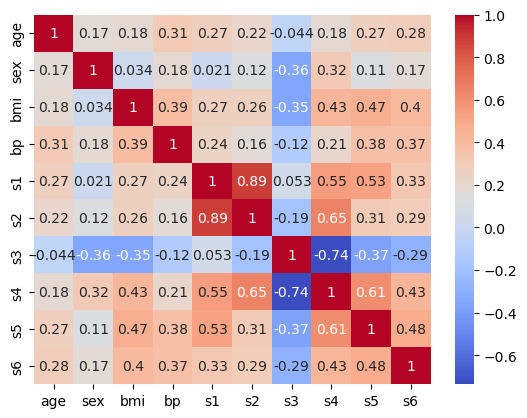

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure()
sns.heatmap(X_train.corr(), annot=True, cmap='coolwarm')

In [17]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
model.fit(X_train,y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


## Hyperparameter Tuning

In [19]:
params={
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
    'splitter': ['best', 'random'],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [20]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV
model = DecisionTreeRegressor()
random_search = RandomizedSearchCV(estimator=model, param_distributions=params, n_iter=100, cv=5, verbose=2, random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)



Fitting 5 folds for each of 100 candidates, totalling 500 fits


,estimator,DecisionTreeRegressor()
,param_distributions,"{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,100
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [21]:
random_search.best_params_
 

{'splitter': 'random',
 'min_samples_split': 2,
 'min_samples_leaf': 4,
 'max_depth': 20,
 'criterion': 'squared_error'}

In [22]:
random_search.best_score_

np.float64(0.2758344410539625)

In [24]:
# predictions
y_pred = random_search.predict(X_test)

In [26]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

R2 Score: 0.3113392392913803
Mean Absolute Error: 48.73033707865169
Mean Squared Error: 3648.629213483146


In [27]:
best_model=DecisionTreeRegressor(criterion='squared_error', 
                                 max_depth=20, 
                                 min_samples_leaf=4, 
                                 min_samples_split=2, 
                                 splitter='random')
best_model.fit(X_train,y_train)
y_pred_best=best_model.predict(X_test)

[Text(0.5156744462025317, 0.9615384615384616, 'x[3] <= -0.015\nsquared_error = 6076.398\nsamples = 353\nvalue = 153.737'),
 Text(0.20727848101265822, 0.8846153846153846, 'x[8] <= -0.036\nsquared_error = 4453.898\nsamples = 147\nvalue = 122.884'),
 Text(0.36147646360759494, 0.9230769230769231, 'True  '),
 Text(0.10126582278481013, 0.8076923076923077, 'x[4] <= -0.033\nsquared_error = 1578.617\nsamples = 54\nvalue = 87.556'),
 Text(0.06329113924050633, 0.7307692307692307, 'x[5] <= -0.047\nsquared_error = 1825.842\nsamples = 36\nvalue = 95.861'),
 Text(0.02531645569620253, 0.6538461538461539, 'x[5] <= -0.071\nsquared_error = 725.49\nsamples = 22\nvalue = 81.682'),
 Text(0.012658227848101266, 0.5769230769230769, 'squared_error = 1028.734\nsamples = 8\nvalue = 94.375'),
 Text(0.0379746835443038, 0.5769230769230769, 'x[9] <= -0.06\nsquared_error = 407.531\nsamples = 14\nvalue = 74.429'),
 Text(0.02531645569620253, 0.5, 'squared_error = 484.56\nsamples = 5\nvalue = 83.8'),
 Text(0.050632911392

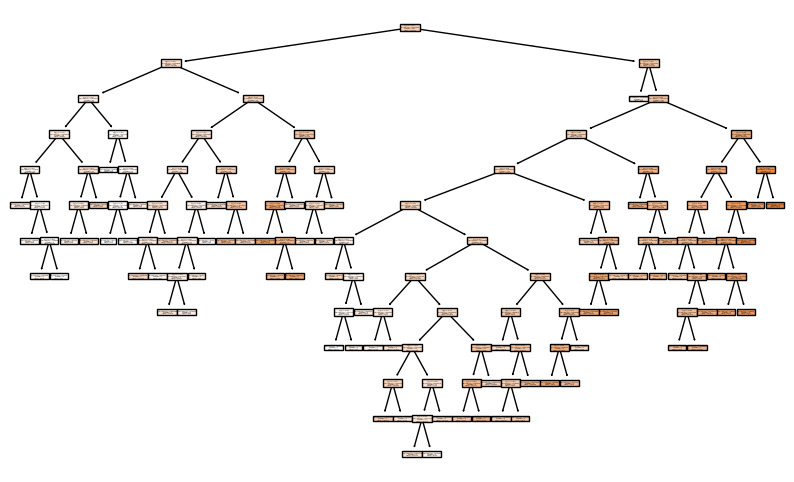

In [28]:

# visualization
from sklearn.tree import plot_tree
plt.figure(figsize=(10,6))
plot_tree(best_model, filled=True)


In [29]:
print("R2 Score:", r2_score(y_test, y_pred_best))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_best))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_best))

R2 Score: 0.2834511826217194
Mean Absolute Error: 50.286062065275544
Mean Squared Error: 3796.38436969024
